# 🎲 Exact Score Prediction — Poisson Model
**World Cup 2026 Predictor** · Can we predict not just who wins, but the exact score?
Football goals famously follow a Poisson distribution — let's verify it and exploit it.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

pd.set_option('display.max_columns', None)

# Artifacts produced by notebook 03
intl = pd.read_csv("../data/processed/internationals_with_elo.csv")
intl["date"] = pd.to_datetime(intl["date"])
elo_ratings = pd.read_csv("../data/processed/elo_ratings_2026.csv")
current_elo = elo_ratings.set_index("team")["elo"].to_dict()

# Modern era only — same logic as the main model
intl_modern = intl[intl["date"].dt.year >= 1990].copy()
print(len(intl_modern), "matches since 1990")

32287 matches since 1990


## 1. Do goals really follow a Poisson distribution?

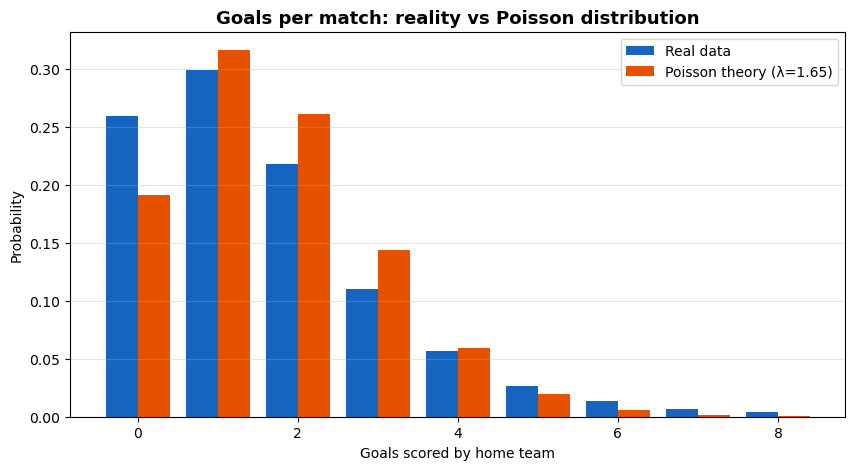

Mean: 1.65 | Variance: 2.94  (perfect Poisson: mean = variance)


In [3]:
# Goals scored by the home team in every match
goals_home = intl_modern["home_score"].astype(int)
lam = goals_home.mean()  # the Poisson parameter: average goals

# Real distribution vs theoretical Poisson with the same mean
max_goals = 8
real_dist = goals_home.value_counts(normalize=True).sort_index().reindex(range(max_goals+1), fill_value=0)
theory_dist = [poisson.pmf(k, lam) for k in range(max_goals+1)]

x = np.arange(max_goals + 1)
plt.figure(figsize=(10, 5))
plt.bar(x - 0.2, real_dist.values, width=0.4, label="Real data", color="#1565C0")
plt.bar(x + 0.2, theory_dist, width=0.4, label=f"Poisson theory (λ={lam:.2f})", color="#E65100")
plt.title("Goals per match: reality vs Poisson distribution", fontsize=13, fontweight="bold")
plt.xlabel("Goals scored by home team")
plt.ylabel("Probability")
plt.legend()
plt.grid(alpha=0.3, axis="y")
plt.show()

print(f"Mean: {goals_home.mean():.2f} | Variance: {goals_home.var():.2f}  (perfect Poisson: mean = variance)")

**Interpretation:** the fit is good but not perfect — reality has more 0s and more blowouts
(5+ goals) than theory predicts. This is **overdispersion**: we pooled every match into a single
average λ=1.65, but a Spain–Cape Verde does not have the same λ as a France–Argentina.
The fix: estimate a **λ per match** based on team strength (Elo) — next section.

## 2. A λ per match — Poisson regression on Elo difference
We model each team's expected goals as a function of the Elo gap. The feature is scaled to
Elo's natural unit (400 points) so the optimizer converges properly.

In [4]:
from sklearn.linear_model import PoissonRegressor

intl_modern["elo_diff"] = intl_modern["elo_home_pre"] - intl_modern["elo_away_pre"]
intl_modern["elo_diff_scaled"] = intl_modern["elo_diff"] / 400  # Elo's natural scale

X = intl_modern[["elo_diff_scaled"]]
poisson_home = PoissonRegressor(alpha=0, max_iter=5000).fit(X, intl_modern["home_score"])
poisson_away = PoissonRegressor(alpha=0, max_iter=5000).fit(X, intl_modern["away_score"])

print(f"Coef home: {poisson_home.coef_[0]:.3f} | Coef away: {poisson_away.coef_[0]:.3f}")
print()

# Sanity check: expected goals at different Elo gaps
for diff in [-400, -200, 0, 200, 400]:
    lh = poisson_home.predict(pd.DataFrame({"elo_diff_scaled": [diff/400]}))[0]
    la = poisson_away.predict(pd.DataFrame({"elo_diff_scaled": [diff/400]}))[0]
    print(f"Elo diff {diff:+5d} → expected score: {lh:.2f} - {la:.2f}")

Coef home: 0.875 | Coef away: -0.901

Elo diff  -400 → expected score: 0.61 - 2.54
Elo diff  -200 → expected score: 0.94 - 1.62
Elo diff    +0 → expected score: 1.46 - 1.03
Elo diff  +200 → expected score: 2.26 - 0.66
Elo diff  +400 → expected score: 3.50 - 0.42


## 3. The score matrix
With a λ for each team, Poisson gives the probability of **every exact score**. The matrix also
yields win/draw/loss probabilities for free: the diagonal is the draw, the lower triangle the
home win, the upper triangle the away win.

In [5]:
def score_matrix(elo_home, elo_away, max_goals=6):
    """Probability of every exact score given two Elo ratings."""
    diff_scaled = (elo_home - elo_away) / 400  # same scaling as training!
    lam_h = poisson_home.predict(pd.DataFrame({"elo_diff_scaled": [diff_scaled]}))[0]
    lam_a = poisson_away.predict(pd.DataFrame({"elo_diff_scaled": [diff_scaled]}))[0]
    matrix = np.outer(
        [poisson.pmf(i, lam_h) for i in range(max_goals+1)],
        [poisson.pmf(j, lam_a) for j in range(max_goals+1)],
    )
    return matrix, lam_h, lam_a


def show_match(home, away, elo_home=None, elo_away=None):
    """Heatmap of exact score probabilities for a match (Elo defaults to current ratings)."""
    elo_home = elo_home if elo_home is not None else current_elo.get(home, 1500)
    elo_away = elo_away if elo_away is not None else current_elo.get(away, 1500)
    matrix, lh, la = score_matrix(elo_home, elo_away)
    n = matrix.shape[0]

    fig, ax = plt.subplots(figsize=(8, 6.5))
    im = ax.imshow(matrix * 100, cmap="Greens")
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xlabel(f"{away} goals"); ax.set_ylabel(f"{home} goals")
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f"{matrix[i,j]*100:.1f}", ha="center", va="center",
                    color="white" if matrix[i,j] > 0.06 else "black", fontsize=9)
    ax.set_title(f"{home} (Elo {elo_home:.0f}) vs {away} (Elo {elo_away:.0f})\n"
                 f"Exact score probabilities (%) — expected goals: {lh:.2f} - {la:.2f}",
                 fontweight="bold")
    plt.colorbar(im, label="%")
    plt.tight_layout(); plt.show()

    flat = [(f"{i}-{j}", matrix[i, j]) for i in range(n) for j in range(n)]
    top5 = sorted(flat, key=lambda t: -t[1])[:5]
    print("Most likely scores:", ", ".join(f"{s} ({p*100:.1f}%)" for s, p in top5))
    p_home = np.tril(matrix, -1).sum()
    p_draw = np.trace(matrix)
    p_away = np.triu(matrix, 1).sum()
    print(f"From the matrix → {home} win: {p_home*100:.1f}% | Draw: {p_draw*100:.1f}% | {away} win: {p_away*100:.1f}%")

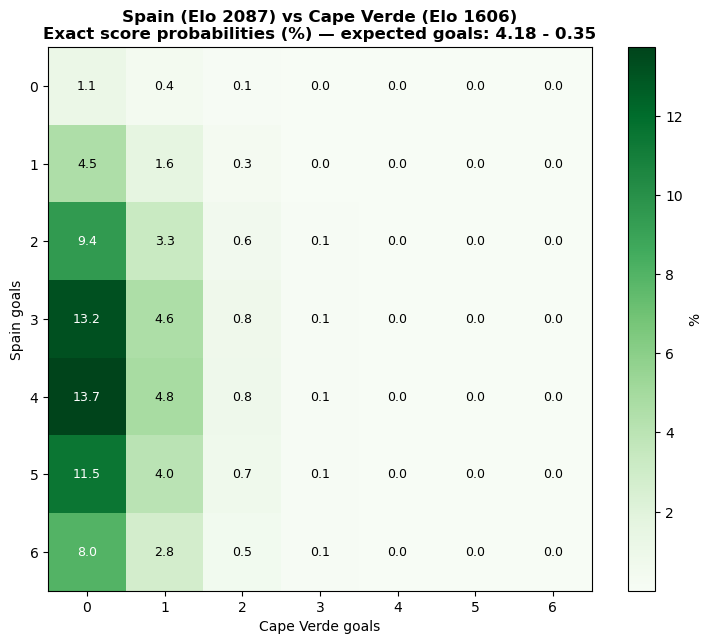

Most likely scores: 4-0 (13.7%), 3-0 (13.2%), 5-0 (11.5%), 2-0 (9.4%), 6-0 (8.0%)
From the matrix → Spain win: 82.8% | Draw: 3.3% | Cape Verde win: 0.8%


In [6]:
# THE TEST: a heavy favourite (real current Elo ratings, no guessing)
show_match("Spain", "Cape Verde")

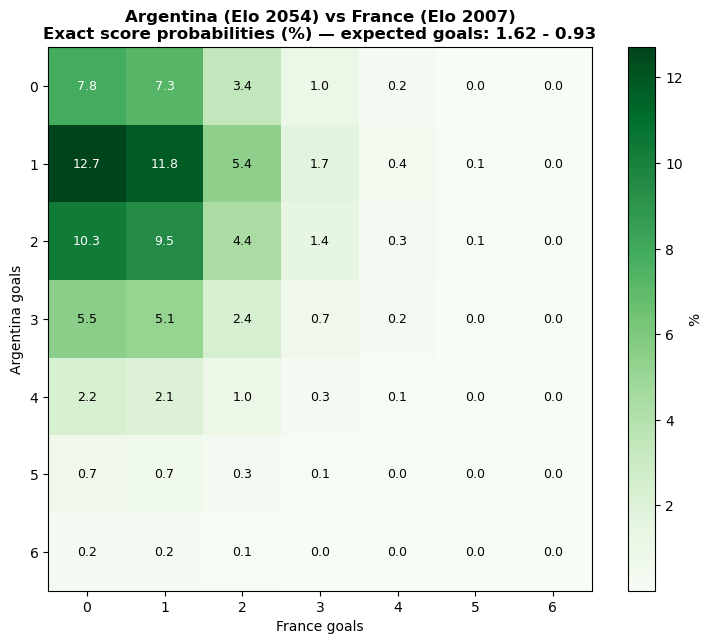

Most likely scores: 1-0 (12.7%), 1-1 (11.8%), 2-0 (10.3%), 2-1 (9.5%), 0-0 (7.8%)
From the matrix → Argentina win: 53.5% | Draw: 24.8% | France win: 21.5%


In [7]:
# A balanced clash between giants
show_match("Argentina", "France")

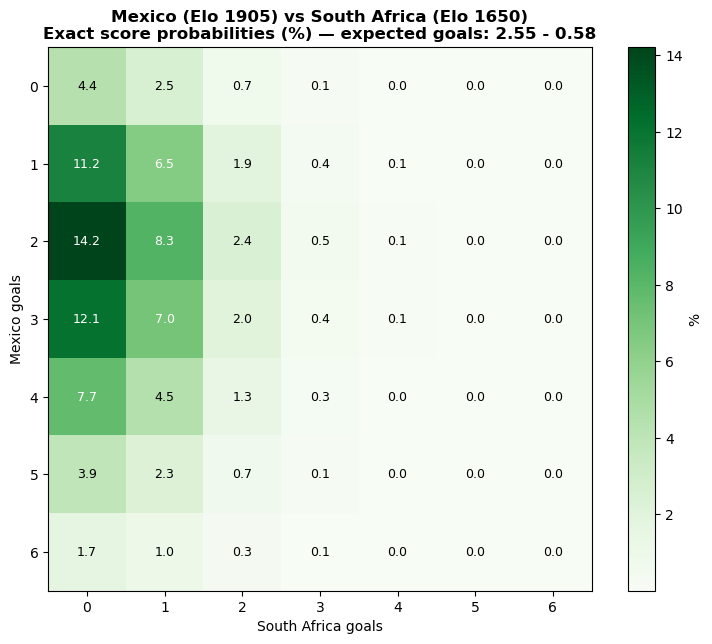

Most likely scores: 2-0 (14.2%), 3-0 (12.1%), 1-0 (11.2%), 2-1 (8.3%), 4-0 (7.7%)
From the matrix → Mexico win: 78.4% | Draw: 13.7% | South Africa win: 6.4%


In [8]:
# Tonight's opener
show_match("Mexico", "South Africa")

## 4. Conclusions and caveats

- **Goals follow Poisson closely enough** to build an exact-score model on top of it
  (with mild overdispersion: more 0-0s and blowouts than pure theory).
- **Most likely exact scores peak around 10-12%** — exact scores are inherently hard;
  the value is in the full probability distribution, not a single guess.
- **The matrix gives 1X2 probabilities for free** — including a principled draw probability,
  which our classifier struggles with. A future model could blend both approaches.
- **Caveats:** the λ regression uses all internationals including non-neutral venues, so part of
  the "home" effect is real home advantage that may not apply at a (mostly) neutral World Cup.
  A refinement would fit separate models for neutral matches or add `neutral` as a feature.
- This notebook is exploratory — promoting exact scores to the production dashboard is on the
  roadmap (v2).

## 5. Neutral-ground adjustment

In [9]:
# Compare home goals in neutral vs non-neutral matches
print(intl_modern.groupby("neutral")[["home_score", "away_score"]].mean().round(2))
print()
print(intl_modern["neutral"].value_counts())

         home_score  away_score
neutral                        
False          1.69        1.01
True           1.55        1.34

neutral
False    23178
True      9109
Name: count, dtype: int64


In [10]:
neutral_only = intl_modern[intl_modern["neutral"] == True]

Xn = neutral_only[["elo_diff_scaled"]]
poisson_home_n = PoissonRegressor(alpha=0, max_iter=5000).fit(Xn, neutral_only["home_score"])
poisson_away_n = PoissonRegressor(alpha=0, max_iter=5000).fit(Xn, neutral_only["away_score"])

print(f"Neutral matches used: {len(neutral_only)}")
print()
print("Expected goals at Elo diff 0 (a perfectly even match):")
print(f"  With home advantage (old): {poisson_home.predict(pd.DataFrame({'elo_diff_scaled':[0]}))[0]:.2f} - {poisson_away.predict(pd.DataFrame({'elo_diff_scaled':[0]}))[0]:.2f}")
print(f"  Neutral ground (new):      {poisson_home_n.predict(pd.DataFrame({'elo_diff_scaled':[0]}))[0]:.2f} - {poisson_away_n.predict(pd.DataFrame({'elo_diff_scaled':[0]}))[0]:.2f}")

Neutral matches used: 9109

Expected goals at Elo diff 0 (a perfectly even match):
  With home advantage (old): 1.46 - 1.03
  Neutral ground (new):      1.37 - 1.27


**Neutral-ground adjustment:** non-neutral matches show a +0.68 goal home edge (1.69 vs 1.01);
on neutral ground it nearly vanishes (1.55 vs 1.34). We keep TWO models: the neutral one for
regular World Cup matches, and the home-advantage one for hosts playing on home soil.